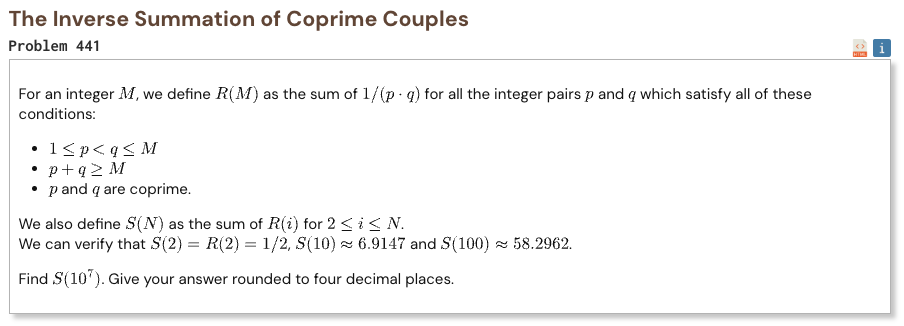

## Initial approach

-   treat the wasted space as the volume above the sloping grain surface
-   for each direction from the delivery point, find how far the silo wall is
-   integrate these distances over every direction to calculate the wasted volume
-   the delivery point can move from the centre to the edge of the silo
-   find which integer squares lie between the minimum and maximum wasted volumes
-   use scipy integration to evaluate the volume accurately and scipy root finding to locate each matching distance
-   add all matching distances and round the sum to 9 decimal places

In [1]:
%%time

import math
from scipy.integrate import quad
from scipy.optimize import brentq

R = 6
alpha = math.radians(40)
tan_alpha = math.tan(alpha)

def volume(x):
    def integrand(theta):
        distance = (
            -x * math.cos(theta)
            + math.sqrt(R * R - x * x * math.sin(theta) ** 2)
        )
        return distance ** 3

    integral = quad(
        integrand,
        0,
        2 * math.pi,
        epsabs=1e-11,
        epsrel=1e-11
    )[0]

    return tan_alpha * integral / 3

min_volume = volume(0)
max_volume = volume(R)

first_square = math.ceil(math.sqrt(min_volume))
last_square = math.floor(math.sqrt(max_volume))

solutions = []

for n in range(first_square, last_square + 1):
    target = n * n

    x = brentq(
        lambda x: volume(x) - target,
        0,
        R,
        xtol=1e-13
    )

    solutions.append(x)

result = sum(solutions)

print("Result:", round(result, 9))

Result: 23.386029052
CPU times: user 1.61 s, sys: 551 ms, total: 2.16 s
Wall time: 989 ms
